import pandas as pd

df_cleaned = pd.read_csv("labeled_cleaned.csv", dtype={
    "image_idx": "uint32",
    "question": "string",
    "answer": "string",
    "file_name": "string",
    "label": "string",
    "id_question": "uint32",
    })

display(df_cleaned.info())

df_rewrite = pd.read_csv("rewrited.csv", dtype={
    "id_question": "uint32",
    "origin_question": "string",
    "rewrite": "string",
    "LLM_labeled": "string",
    })
display(df_rewrite.info())

df_merge = df_cleaned.merge(df_rewrite, on="id_question", how="left")
display(df_merge.info())

df_merge['rewrite'] = df_merge['rewrite'].combine_first(df_merge['question'])

df_lean = df_merge[['image_idx', 'file_name', 'question', 'rewrite', 'answer', 'label']]

df_lean.at[61, 'label'] = 'location'
df_lean.at[419, 'label'] = 'attribute'
df_lean.at[1143, 'label'] = 'location'
df_lean.at[1571, 'label'] = 'location'
df_lean.at[1578, 'label'] = 'yes_no'
df_lean.at[2002, 'label'] = 'object'

df_lean[df_lean['label'].str.len() > 11]
df_lean.to_csv("lean.csv", index=False)

In [ ]:
import pandas as pd

df_lean = pd.read_csv("merged.csv", dtype= {
    "image_idx": "uint32",
    "file_name": "string",
    "question": "string",
    "answer": "string",
    "rewrite": "string",
    "label": "string",
})

df_lean.info()

# Lọc các dòng chứa ít nhất một ký tự tiếng Trung
# df_lean[df_lean['rewrite'].str.contains(r'[\u4e00-\u9fff]', na=False)]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2670 entries, 0 to 2669
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_idx   2670 non-null   uint32
 1   image_path  2670 non-null   object
 2   question    2670 non-null   string
 3   answer      2670 non-null   string
dtypes: object(1), string(2), uint32(1)
memory usage: 73.1+ KB


In [ ]:
len(df_lean['image_idx'].unique())

967

/tmp/ipykernel_529/2097294672.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')


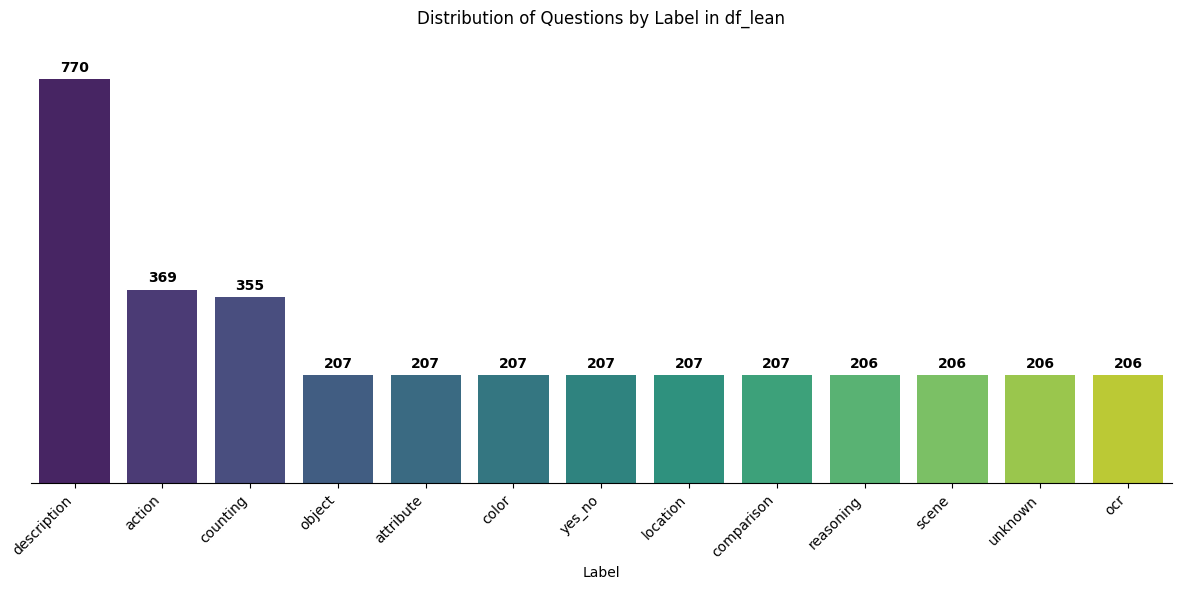

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tính toán số lượng
label_counts = df_lean['label'].value_counts()

plt.figure(figsize=(12, 6))
# Vẽ barplot - gán vào biến ax
ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')

# HIỂN THỊ SỐ TRÊN ĐỈNH TẤT CẢ CÁC CỘT
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10, fontweight='bold')

# LOẠI BỎ TRỤC TUNG VÀ KHUNG HÌNH
ax.yaxis.set_visible(False) # Ẩn trục Y
sns.despine(left=True, top=True, right=True) # Xóa các đường bao quanh

plt.title('Distribution of Questions by Label in df_lean', pad=25)
plt.xlabel('Label')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


In [ ]:
label_counts = df_lean['label'].value_counts()
# label_counts.to_csv("label_counts.csv")
display(label_counts)

,count
label,
description,770
action,369
counting,355
object,207
attribute,207
color,207
yes_no,207
location,207
comparison,207


In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "QaA.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "bnquys/qaa-for-generative-vqa",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

display("First 5 records:", df.head())

/tmp/ipykernel_9987/898083816.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'qaa-for-generative-vqa' dataset.


'First 5 records:'

,image_idx,question,answer
0,0,Người trượt ván đang làm gì?,Người trượt ván đang thực hiện động tác trượt ...
1,0,Bức tường mà người trượt ván đang trượt là loạ...,Bức tường mà người trượt ván đang trượt là một...
2,0,Người trượt ván đang mặc gì?,"Người trượt ván mặc áo hoodie màu xanh lam, qu..."
3,0,Trò chơi nào mà người trượt ván đang thực hiện...,"Dựa trên hình ảnh, không rõ người trượt ván đa..."
4,0,Bạn có thể cho tôi biết thêm thông tin về động...,Trượt ván là một môn thể thao hành động liên q...


In [ ]:
df[df['image_idx'] == 5892]

,image_idx,question,answer
25656,5892,Bờ sông mà con bò nằm có đặc điểm gì khác biệt?,Bờ sông mà con bò nằm có một con đường mòn nhỏ...


In [ ]:
# Đếm và đặt tên cột rõ ràng
df_counts = df_lean.groupby('image_idx').size().reset_index(name='question_count')

display(df_counts.sort_values(by='question_count'))
# df_counts.to_csv("question_count.csv", index=False)

,image_idx,question_count
960,166500,1
959,166069,1
958,165644,1
957,165576,1
956,165284,1
...,...,...
473,82789,6
30,4143,7
241,43878,7
447,78661,7


In [ ]:
import pandas as pd
import random

# Đọc dữ liệu từ hai file thống kê của bạn
df_labels = pd.read_csv('label_counts.csv')
df_questions = pd.read_csv('question_count.csv')

# BƯỚC 1: Lọc các ảnh đang thiếu câu hỏi và tính tổng số cần bù
df_questions['missing_count'] = 3 - df_questions['question_count']
df_missing = df_questions[df_questions['missing_count'] > 0].copy()

total_needed = df_missing['missing_count'].sum()

# BƯỚC 2: Chuẩn bị rổ nhãn mục tiêu
# Gạt nhãn 'description' ra khỏi cuộc chơi
target_labels = df_labels.copy()

# Chuyển đổi dữ liệu nhãn thành dạng từ điển (dictionary) để xử lý cho mượt
current_counts = target_labels.set_index('label')['count'].to_dict()
assigned_counts = {label: 0 for label in current_counts}

# BƯỚC 3: Cân bằng nhãn bằng chiến thuật đổ nước
# Liên tục thả 1 đơn vị vào nhãn đang có tổng số (cũ + mới) còm nhom nhất
for _ in range(total_needed):
    min_label = min(current_counts.keys(), key=lambda k: current_counts[k] + assigned_counts[k])
    assigned_counts[min_label] += 1

# Tạo một danh sách xả phẳng chứa toàn bộ nhãn mới chuẩn bị đem gán
new_labels_pool = []
for label, count in assigned_counts.items():
    new_labels_pool.extend([label] * count)

# Xóc bộ bài nhãn lên để phân phối cho đều, tránh bị dồn cục một chỗ
random.shuffle(new_labels_pool)

# BƯỚC 4: Phân phát nhãn cho các ảnh đang thiếu
final_assignments = []
pool_index = 0

for _, row in df_missing.iterrows():
    img_idx = int(row['image_idx'])
    missing = int(row['missing_count'])

    # Bốc đủ số lượng nhãn từ trong rổ ra đưa cho ảnh này
    assigned_labels = new_labels_pool[pool_index : pool_index + missing]

    for label in assigned_labels:
        final_assignments.append({
            'image_idx': img_idx,
            'required_label': label
        })

    pool_index += missing

# Đóng gói kết quả thành một bảng dữ liệu sạch sẽ (DataFrame)
df_required = pd.DataFrame(final_assignments)

# In thử vài dòng đầu để kiểm nghiệm thành quả
print("Danh sách các câu hỏi cần tạo thêm cho từng ảnh:")
display(df_required)

# Mở khóa dòng bên dưới để lưu thẳng kết quả ra file mới phục vụ cho khâu sinh dữ liệu
df_required.to_csv('required.csv', index=False)

Danh sách các câu hỏi cần tạo thêm cho từng ảnh:


,image_idx,required_label
0,5892,scene
1,5892,location
2,11700,comparison
3,13776,ocr
4,29159,attribute
...,...,...
991,167753,ocr
992,167948,attribute
993,167948,ocr
994,168010,yes_no


In [ ]:
from pathlib import Path

def get_questions_by_idx(df, target_idx, label):
    # Lọc dataframe theo image_idx và lấy cột 'question'
    questions = df.loc[(df['image_idx'] == target_idx) & (df['label'] == label), 'question']

    # Chuyển kết quả sang dạng list
    return "\n".join(questions.tolist())

def get_filename_by_idx(df, target_idx):
    # Lọc các dòng có image_idx khớp
    result = df.loc[df['image_idx'] == target_idx, 'file_name']

    # Trả về tên file đầu tiên nếu tìm thấy, ngược lại trả về None
    return result.iloc[0] if not result.empty else None

In [ ]:
!uv pip install bitsandbytes accelerate qwen-vl-utils

Using Python 3.12.13 environment at: /usr
Checked 3 packages in 288ms


In [ ]:
import torch
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
from qwen_vl_utils import process_vision_info

class QwenVLBatchProcessor:
    def __init__(self, model_id="Qwen/Qwen2.5-VL-7B-Instruct"):
        """Khởi tạo mô hình tối ưu cho GPU T4"""
        print(f"Đang tải mô hình {model_id}...")
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_use_double_quant=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.float16
        )

        self.model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
            model_id,
            quantization_config=bnb_config,
            device_map="auto"
        )
        self.processor = AutoProcessor.from_pretrained(model_id)

        # SỬA ĐỔI 1: Sử dụng từ điển (dictionary) để quản lý mã lệnh cho nhiều nhiệm vụ
        self.system_prompts = {}
        print("Khởi tạo hoàn tất.")

    def set_system_prompt(self, task_name, system_prompt):
        """
        SỬA ĐỔI 2: Thiết lập mã lệnh hệ thống (system prompt) theo từng nhiệm vụ.
        Ví dụ task_name có thể là 'answer' hoặc 'generate_question'.
        """
        self.system_prompts[task_name] = system_prompt
        print(f"Đã cập nhật System Prompt cho nhiệm vụ: {task_name}")

    def _prepare_image_source(self, image_source):
        """Hàm nội bộ xử lý đường dẫn ảnh"""
        if str(image_source).startswith("/"):
            return f"file://{image_source}"
        return image_source

    def generate_response(self, image_source, question, max_new_tokens=128, extract_keyword="Câu trả lời:"):
        """
        Nhiệm vụ: Trả lời câu hỏi dựa trên ảnh và tự động bóc tách kết quả.
        Tham số extract_keyword mặc định là 'Câu trả lời:' để tự động cắt bỏ tiền tố rườm rà.
        """
        image_source = self._prepare_image_source(image_source)

        sys_prompt = self.system_prompts.get("answer", "Bạn là chuyên gia phân tích hình ảnh AI.")

        messages = [
            {"role": "system", "content": sys_prompt},
            {"role": "user", "content": [
                {"type": "image", "image": image_source},
                {"type": "text", "text": question}
            ]}
        ]

        # Nhận kết quả thô từ mô hình
        raw_output = self._inference(messages, max_new_tokens)

        # Gọi thẳng hàm parse_response bên trong class để làm sạch dữ liệu
        return self._parse_response(raw_output, extract_keyword)

    def _parse_response(self, raw_response, extract_keyword=None):
        """Hàm nội bộ giúp làm sạch và bóc tách phản hồi"""
        clean_text = raw_response.strip()

        if extract_keyword and extract_keyword in clean_text:
            return clean_text.split(extract_keyword)[-1].strip()

        return clean_text

    def generate_question_by_label(self, image_source, label, existing_questions=None, max_new_tokens=50):
        """
        SỬA ĐỔI 3: Sinh câu hỏi không trùng lặp và không bắt buộc liên quan đến ảnh.
        Tham số existing_questions nhận vào một danh sách (list) các câu hỏi đã tạo.
        """
        image_source = self._prepare_image_source(image_source)

        # Lấy mã lệnh tương ứng với nhiệm vụ tạo dữ liệu
        sys_prompt = self.system_prompts.get("generate_question", "Bạn là chuyên gia tạo dữ liệu.")

        # Xây dựng yêu cầu cốt lõi (User Request)
        user_request = f"Hãy đặt một câu hỏi tiếng Việt thuộc loại nhãn '{label}'. Câu hỏi này KHÔNG bắt buộc phải liên quan trực tiếp đến các chi tiết có trong hình ảnh. Đảm bảo câu hỏi tự nhiên và dưới 10 từ đơn."

        # Xử lý logic chống trùng lặp nếu có dữ liệu cũ
        if existing_questions and len(existing_questions) > 0:
            # Nối các câu hỏi cũ thành một danh sách văn bản
            danh_sach_cu = "\n- ".join(existing_questions)
            user_request += f"\n\nTuyệt đối KHÔNG tạo câu hỏi trùng lặp ý nghĩa hoặc cấu trúc với các câu sau:\n- {danh_sach_cu}"

        messages = [
            {"role": "system", "content": sys_prompt},
            {"role": "user", "content": [
                {"type": "image", "image": image_source},
                {"type": "text", "text": user_request}
            ]}
        ]

        raw_output = self._inference(messages, max_new_tokens)
        return raw_output.replace("Câu hỏi:", "").strip()

    def _inference(self, messages, max_new_tokens):
        """Hàm nội bộ xử lý luồng suy luận của mô hình"""
        text = self.processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        image_inputs, video_inputs = process_vision_info(messages)

        inputs = self.processor(
            text=[text],
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            return_tensors="pt",
        ).to(self.model.device)

        with torch.no_grad():
            generated_ids = self.model.generate(**inputs, max_new_tokens=max_new_tokens)

        generated_ids_trimmed = [
            out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
        ]

        return self.processor.batch_decode(
            generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
        )[0].strip()

    def generate_diverse_answer(self, image_source, question, existing_answers=None, max_new_tokens=128, extract_keyword="Câu trả lời:"):
        """
        Nhiệm vụ: Trả lời câu hỏi dựa trên ảnh nhưng không được trùng lặp với danh sách câu trả lời đã có.
        """
        image_source = self._prepare_image_source(image_source)

        # Lấy mã lệnh tương ứng với nhiệm vụ trả lời đa dạng
        sys_prompt = self.system_prompts.get("diverse_answer", "Bạn là chuyên gia phân tích hình ảnh AI.")

        # Xây dựng yêu cầu cốt lõi
        user_request = f"Câu hỏi: {question}"

        # Xử lý logic chống trùng lặp nếu có dữ liệu cũ
        if existing_answers and len(existing_answers) > 0:
            danh_sach_cu = "\n- ".join(existing_answers)
            user_request += f"\n\nYêu cầu bắt buộc: Dựa vào hình ảnh, hãy trả lời câu hỏi trên. Tuyệt đối KHÔNG được lặp lại ý tưởng, thông tin hoặc cách diễn đạt của các câu trả lời sau đây:\n- {danh_sach_cu}\n\nHãy quan sát kỹ hình ảnh để tìm một chi tiết khác, góc nhìn khác, hoặc cung cấp một thông tin bổ sung hoàn toàn mới để trả lời."

        messages = [
            {"role": "system", "content": sys_prompt},
            {"role": "user", "content": [
                {"type": "image", "image": image_source},
                {"type": "text", "text": user_request}
            ]}
        ]

        # Nhận kết quả thô từ mô hình
        raw_output = self._inference(messages, max_new_tokens)

        # Làm sạch dữ liệu
        return self._parse_response(raw_output, extract_keyword)

qwen_processor = QwenVLBatchProcessor()

Đang tải mô hình Qwen/Qwen2.5-VL-7B-Instruct...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Khởi tạo hoàn tất.


In [ ]:
# Khai báo mã lệnh hệ thống cho nhiệm vụ trả lời đa dạng
DIVERSE_ANSWER_SYSTEM_PROMPT = """Bạn là chuyên gia phân tích hình ảnh AI cao cấp, chuyên gia tạo dữ liệu đa góc nhìn.
Nhiệm vụ: Trả lời câu hỏi dựa trên hình ảnh một cách tự nhiên, nhưng phải tìm ra các chi tiết mới mẻ, độc đáo hoặc diễn đạt theo một hướng tiếp cận khác biệt hoàn toàn so với các câu trả lời đã có.
Lưu ý:
- Phải trả lời đúng trọng tâm câu hỏi, không bịa đặt thông tin ngoài bức ảnh.
- Nếu không còn chi tiết nào mới để khai thác, hãy mở rộng ngữ cảnh, giải thích thêm về chi tiết đó, hoặc thay đổi hoàn toàn cấu trúc câu.
- Ngôn ngữ sử dụng là tiếng Việt thuần túy, tự nhiên.
- Luôn tuân thủ định dạng: Câu trả lời: <nội dung phản hồi>"""

# Nạp mã lệnh vào hệ thống
qwen_processor.set_system_prompt("diverse_answer", DIVERSE_ANSWER_SYSTEM_PROMPT)

# Chạy thử nghiệm
duong_dan_anh = "/content/images/000563.jpg"
cau_hoi_thu = "Bức ảnh này mô tả cảnh gì?"

# Giả sử chúng ta đã có 2 câu trả lời trước đó
cac_cau_tra_loi_cu = [
    "Đây là một cánh đồng cỏ xanh mướt với đàn bò đang ăn cỏ.",
    "Bức tranh vẽ cảnh một nông trại chăn nuôi bò sữa vào ban ngày."
]

print("\n--- BẮT ĐẦU SINH CÂU TRẢ LỜI ĐA DẠNG ---")
print(f"Câu hỏi gốc: {cau_hoi_thu}")

# Gọi hàm sinh câu trả lời mới
cau_tra_loi_moi = qwen_processor.generate_diverse_answer(
    image_source=duong_dan_anh,
    question=cau_hoi_thu,
    existing_answers=cac_cau_tra_loi_cu,
    max_new_tokens=100
)

print(f"Câu trả lời mới: {cau_tra_loi_moi}")

Đã cập nhật System Prompt cho nhiệm vụ: diverse_answer

--- BẮT ĐẦU SINH CÂU TRẢ LỜI ĐA DẠNG ---
Câu hỏi gốc: Bức ảnh này mô tả cảnh gì?
Câu trả lời mới: Bức ảnh này cho thấy hai con bò đang đứng cạnh nhau trên một cánh đồng cỏ xanh mướt. Đôi mắt của chúng to tròn và ánh nhìn thẳng vào camera, tạo nên cảm giác gần gũi và thân thiện. Bạn có thể thấy những con bò khác đang nghỉ ngơi ở phía sau, tạo nên một khung cảnh yên bình và tự nhiên.


In [ ]:
# Khai báo bộ lệnh hệ thống dành riêng cho nhiệm vụ sinh câu hỏi
GEN_QUESTION_SYSTEM_PROMPT = """
Bạn là chuyên gia tạo dữ liệu Generative VQA.
Nhiệm vụ: Nhìn ảnh và đặt câu hỏi tiếng Việt duy nhất dựa trên nhãn được yêu cầu.

QUY TẮC BẮT BUỘC:
1. NGÔN NGỮ: Chỉ được sử dụng tiếng Việt. Tuyệt đối không trả về bất kỳ từ tiếng Anh nào (Trừ khi tên riêng).
2. ĐỊNH DẠNG: Phải là một câu hỏi (kết thúc bằng dấu chấm hỏi). Tuyệt đối không trả về câu trần thuật hay mô tả.
3. ĐỘ DÀI: Tuyệt đối dưới 10 từ đơn.
4. NHÃN OCR: Dù là nhãn OCR, bạn vẫn phải đặt một CÂU HỎI về nội dung văn bản đó, không được chỉ trích xuất chữ.

DANH SÁCH NHÃN:
- ocr: Trích xuất văn bản/số định danh (tên, biển số, ngày tháng).
- counting: Đếm số lượng thực thể rời rạc.
- object: Tên gọi thực thể, con người, vật.
- color: Màu sắc.
- location: Vị trí, phương hướng.
- action: Hành động đang diễn ra.
- attribute: Đặc điểm, tính chất, chất liệu.
- yes_no: Xác nhận đúng/sai.
- reasoning: Giải thích nguyên nhân, logic.
- comparison: So sánh/lựa chọn (A hay B).
- scene: Bối cảnh, thời tiết tổng thể.
- description: Mô tả chi tiết."""

# Nạp bộ lệnh vào hệ thống với tên nhiệm vụ tương ứng
qwen_processor.set_system_prompt("generate_question", GEN_QUESTION_SYSTEM_PROMPT)

Đã cập nhật System Prompt cho nhiệm vụ: generate_question


In [ ]:
# Khai báo nội dung mã lệnh hệ thống cho nhiệm vụ trả lời
ANSWER_SYSTEM_PROMPT = """Bạn là chuyên gia phân tích hình ảnh AI cao cấp.
Nhiệm vụ: Dựa vào hình ảnh được cung cấp, hãy trả lời các câu hỏi một cách tự nhiên, trôi chảy và đầy đủ ý nghĩa.
Lưu ý:
- Đi thẳng vào nội dung chính, tránh dẫn dắt rườm rà nhưng không được trả lời quá cụt ngủn.
- Ngôn ngữ sử dụng phải là tiếng Việt thuần túy, tự nhiên như văn nói của người bản xứ.
- Luôn tuân thủ định dạng: Câu trả lời: <nội dung phản hồi>"""

# Thiết lập mã lệnh vào hệ thống với từ khóa 'answer'
qwen_processor.set_system_prompt("answer", ANSWER_SYSTEM_PROMPT)

Đã cập nhật System Prompt cho nhiệm vụ: answer


from tqdm.auto import tqdm
import csv
from pathlib import Path

# image_ids = df_required['image_idx'].to_list()

count = 0

with open('addition.csv', mode='w', newline='', encoding='utf-8') as f:
  writer = csv.writer(f)
  writer.writerow(['image_idx', 'file_name', 'question', 'rewrite', 'answer', 'label'])
  with tqdm(total=len(df_required), desc="Generating Questions") as pbar:
      for row in df_required.itertuples(index=False):
        idx = row.image_idx
        lbl = row.required_label

        img_file = get_filename_by_idx(df_lean, idx)
        img = str((Path('images') / Path(img_file)).resolve())
        had_q = get_questions_by_idx(df_lean, idx)

        new_q = qwen_processor.generate_question_by_label(
            image_source=img,
            label=lbl,
            existing_questions=had_q
        )

        new_a = qwen_processor.generate_response(
            img,
            new_q
        )

        new_row = [idx, img_file, new_q, new_q, new_a, lbl]
        writer.writerow(new_row)
        
        df_lean.loc[len(df_lean)] = new_row

        df_lean.to_csv("lean.csv", index=False)
        pbar.update(1)

        # count = count + 1
        # if count > 10:
        #   df_lean.to_csv("lean.csv", index=False)
        #   break
